# 02 — 第一代：Heuristic Filtering

**方法论定位（第一代）**：人工设计规则，按 FineWeb 实际过滤顺序执行。

| 步骤 | 过滤器 | 检测目标 | 论文参考值（条件过滤率） | 论文来源 |
|------|--------|---------|----------------------|---------|
| Step 0 | URL 去重 | 完全相同 URL 的重复文档 | ~10-14% | RefinedWeb（多 crawl 聚合场景） |
| Step 1 | URL Filter | 垃圾域名、黑名单 TLD | ~2.1% | FineWeb |
| Step 2 | 语言过滤 | 非英文文档 | ~60%（非英文占比） | RefinedWeb |
| Step 3 | Quality Filter | 文档级+行级统计异常 | ~20-30%（估算） | Gopher / C4 / FineWeb 子规则串行 |
| Step 4 | 重复过滤 | 文档内行级/N-gram 重复 | ~10-15% | Gopher Table A1 |
| Step 5 | PII 脱敏 | 邮箱/电话/IP 地址 | <1%（脱敏，非过滤） | RefinedWeb |

> **口径说明**：论文参考值 = 该步骤丢弃的文档数 / 该步骤的输入文档数（条件过滤率）。来源为各论文原始报告值，与 NB00 §1.1 一致。
>
> **CC WET 数据特性提示**：本项目使用的 CC WET 原始数据比论文常用数据集更脏（噪音比例更高），实际过滤率可能显著高于论文参考值。例如：重复过滤在 Gopher 的 MassiveWeb 上为 ~10-15%，但 CC WET 的 Web 页面模板重复更普遍，实际可达 30-50%。详细对比见下方分析 cells。

**本代的核心价值和局限**：
- 可解释、极快、不需要训练
- 能过滤"明显的垃圾"（乱码、广告、模板）
- 无法区分"平庸内容"和"高质量内容"（都能通过规则）
- 规则之间无协同，阈值靠经验

> 本 notebook 读取 pipeline 预计算结果（`data/gen1_output/`），不再逐步运行过滤器。
> Pipeline 脚本：`scripts/run_gen1.py` | 分析脚本：`scripts/gen1_filter_analysis.py`

In [1]:
# === Cell 1: 环境初始化 + 双模式数据加载 ===
import sys
sys.path.insert(0, '..')
import json
import random
import re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from src.utils.config_loader import load_run_config, get_output_path, print_config_summary

# --- 双模式数据加载 ---
MODES = ['smoke_test', 'full_run']
MODE_LABELS = {'smoke_test': 'Smoke Test (12K)', 'full_run': 'Full Run (100K)'}
dual_data = {}

# --- 依赖文件校验（双模式） ---
ROOT = Path('..')
REQUIRED_FILES = {
    'CC WET 输入': ROOT / 'data/raw/cc_wet_sample.jsonl',
}
for mode in MODES:
    _cfg = load_run_config(run_mode_override=mode)
    _dir = get_output_path(1, _cfg)
    REQUIRED_FILES[f'Gen1 统计 ({mode})'] = _dir / 'gen1_pipeline_stats.json'
    REQUIRED_FILES[f'Gen1 输出 ({mode})'] = _dir / 'gen1_output.jsonl'

for name, path in REQUIRED_FILES.items():
    assert path.exists(), f"缺少 {name}: {path}\n请先运行: python3 scripts/run_gen1.py"
print(f"依赖文件校验通过（{len(REQUIRED_FILES)} 个文件）")

for mode in MODES:
    mode_cfg = load_run_config(run_mode_override=mode)
    gen1_dir = get_output_path(1, mode_cfg)

    stats_path = gen1_dir / 'gen1_pipeline_stats.json'
    with open(stats_path) as f:
        pipeline_data = json.load(f)

    stage_metrics_path = gen1_dir / 'gen1_stage_metrics.json'
    stage_metrics = []
    if stage_metrics_path.exists():
        with open(stage_metrics_path) as f:
            stage_metrics = json.load(f)

    # 加载详细过滤分析
    analysis_path = gen1_dir / 'gen1_filter_analysis.json'
    filter_analysis = None
    if analysis_path.exists():
        with open(analysis_path) as f:
            filter_analysis = json.load(f)

    dual_data[mode] = {
        'cfg': mode_cfg,
        'gen1_dir': gen1_dir,
        'pipeline_stats': pipeline_data['pipeline_stats'],
        'input_count': pipeline_data['input_count'],
        'output_count': pipeline_data['output_count'],
        'retention_rate': pipeline_data['retention_rate'],
        'stage_metrics': stage_metrics,
        'filter_analysis': filter_analysis,
    }
    print(f"[{mode}] 输入: {pipeline_data['input_count']:,} | "
          f"输出: {pipeline_data['output_count']:,} | "
          f"保留率: {pipeline_data['retention_rate']:.1%}"
          f" | 详细分析: {'有' if filter_analysis else '无'}")

# 详细分析使用当前 run_mode（跟随 configs/run_config.yaml 设置）
# 优先 full_run（数据量大，统计更可靠）；如无 full_run 数据则 fallback 到 smoke_test
_active_cfg = load_run_config()
current_mode = _active_cfg.get('run_mode', 'smoke_test')
if current_mode not in dual_data:
    current_mode = 'smoke_test'
print(f"\n当前详细分析模式: {current_mode} (来自 run_config.yaml)")
run_cfg = dual_data[current_mode]['cfg']

# 加载原始文档样本和输出文档
raw_docs = []
cc_wet = Path('../data/raw/cc_wet_sample.jsonl')
with open(cc_wet) as f:
    for i, line in enumerate(f):
        if i >= run_cfg['doc_limit']:
            break
        try:
            raw_docs.append(json.loads(line))
        except Exception:
            pass

output_path = dual_data[current_mode]['gen1_dir'] / 'gen1_output.jsonl'
gen1_docs = []
with open(output_path) as f:
    for line in f:
        try:
            gen1_docs.append(json.loads(line))
        except Exception:
            pass

print(f"原始文档: {len(raw_docs):,} 条 | Gen1 输出: {len(gen1_docs):,} 条")

依赖文件校验通过（5 个文件）
[smoke_test] 输入: 12,000 | 输出: 409 | 保留率: 3.4% | 详细分析: 有
[full_run] 输入: 100,000 | 输出: 3,242 | 保留率: 3.2% | 详细分析: 有

当前详细分析模式: full_run (来自 run_config.yaml)


原始文档: 12,000 条 | Gen1 输出: 3,242 条


## A. 逐阶段过滤总览

双模式对比表，每个过滤器显示：输入 → 输出（分子/分母 = 过滤率），对比工业界预期值。

In [2]:
# === Cell 2: 双模式逐阶段对比表（pandas DataFrame + 论文参考值） ===
step_names = {
    'url_dedup': 'URL 去重',
    'url_filter': 'URL 过滤',
    'language_filter': '语言过滤',
    'quality_filter': '质量过滤(Gopher+C4+FineWeb)',
    'repetition_filter': '重复过滤',
    'pii_filter': 'PII 脱敏',
}

# 论文参考值（条件过滤率，与 NB00 §1.1 一致）
PAPER_REFERENCE = {
    'url_dedup': ('~10-14%', 'RefinedWeb 多crawl；本项目单segment重复率低'),
    'url_filter': ('~2.1%', 'FineWeb UT1 黑名单'),
    'language_filter': ('~60%', 'RefinedWeb；CC WET 随机segment非英文更高'),
    'quality_filter': ('~20-30%', 'Gopher+C4+FineWeb 串行；CC WET更脏'),
    'repetition_filter': ('~10-15%', 'Gopher Table A1；CC WET模板重复率高'),
    'pii_filter': ('<1%', '脱敏模式不删除文档'),
}

mode_step_map = {}
for mode in MODES:
    mode_step_map[mode] = {s['step']: s for s in dual_data[mode]['pipeline_stats']}

all_steps = [s['step'] for s in dual_data['smoke_test']['pipeline_stats']]
_ML = {'smoke_test': 'ST(12K)', 'full_run': 'FR(100K)'}

# --- 构建 DataFrame ---
rows = []
for step in all_steps:
    name = step_names.get(step, step)
    ref_val, ref_note = PAPER_REFERENCE.get(step, ('N/A', ''))
    row = {'过滤器': name}
    
    for mode in MODES:
        ml = _ML[mode]
        s = mode_step_map[mode].get(step)
        if s:
            row[f'{ml} 输入'] = f"{s['before']:,}"
            row[f'{ml} 输出'] = f"{s['after']:,}"
            row[f'{ml} 条件过滤率'] = f"{s['filter_rate']:.1%}"
        else:
            row[f'{ml} 输入'] = 'N/A'
            row[f'{ml} 输出'] = 'N/A'
            row[f'{ml} 条件过滤率'] = 'N/A'
    
    row['论文参考值'] = ref_val
    row['参考说明'] = ref_note
    rows.append(row)

# 总计行
total_row = {'过滤器': '【总计 e2e】'}
for mode in MODES:
    ml = _ML[mode]
    d = dual_data[mode]
    total_row[f'{ml} 输入'] = f"{d['input_count']:,}"
    total_row[f'{ml} 输出'] = f"{d['output_count']:,}"
    total_row[f'{ml} 条件过滤率'] = f"{1-d['retention_rate']:.1%}（总过滤率）"
total_row['论文参考值'] = '60-70%'
total_row['参考说明'] = '综合论文预期 e2e 过滤率'
rows.append(total_row)

step_df = pd.DataFrame(rows)

print("=" * 80)
print("  第一代 Heuristic Filtering — 双模式逐阶段对比")
print("=" * 80)
display(step_df)

# 口径说明
print()
print("口径说明：")
print("  - 条件过滤率 = 分子：该步丢弃文档数 / 分母：该步输入文档数（非原始总量）")
print("  - 论文参考值来源与 NB00 §1.1 一致")
print("  - CC WET 与论文偏差原因：CC WET 原始数据更脏（非英文 ~75%，Web 模板多），")
print("    语言过滤和重复过滤偏离最大")

# 两档一致性
smoke_rate = dual_data['smoke_test']['retention_rate']
full_rate = dual_data['full_run']['retention_rate']
diff_pct = abs(smoke_rate - full_rate) / full_rate * 100 if full_rate > 0 else 0
print(f"\n两档保留率: Smoke={smoke_rate:.2%}, Full={full_rate:.2%}, 差异={diff_pct:.1f}%",
      f"（{'一致性良好' if diff_pct < 20 else '存在显著差异'}）")

  第一代 Heuristic Filtering — 双模式逐阶段对比


,过滤器,ST(12K) 输入,ST(12K) 输出,ST(12K) 条件过滤率,FR(100K) 输入,FR(100K) 输出,FR(100K) 条件过滤率,论文参考值,参考说明
0,URL 去重,"12,000","11,997",0.0%,"100,000","99,896",0.1%,~10-14%,RefinedWeb 多crawl；本项目单segment重复率低
1,URL 过滤,"11,997","11,851",1.2%,"99,896","98,452",1.4%,~2.1%,FineWeb UT1 黑名单
2,语言过滤,"11,851","2,912",75.4%,"98,452","24,026",75.6%,~60%,RefinedWeb；CC WET 随机segment非英文更高
3,质量过滤(Gopher+C4+FineWeb),"2,912",832,71.4%,"24,026","6,539",72.8%,~20-30%,Gopher+C4+FineWeb 串行；CC WET更脏
4,重复过滤,832,409,50.8%,"6,539","3,242",50.4%,~10-15%,Gopher Table A1；CC WET模板重复率高
5,PII 脱敏,409,409,0.0%,"3,242","3,242",0.0%,<1%,脱敏模式不删除文档
6,【总计 e2e】,"12,000",409,96.6%（总过滤率）,"100,000","3,242",96.8%（总过滤率）,60-70%,综合论文预期 e2e 过滤率



口径说明：
  - 条件过滤率 = 分子：该步丢弃文档数 / 分母：该步输入文档数（非原始总量）
  - 论文参考值来源与 NB00 §1.1 一致
  - CC WET 与论文偏差原因：CC WET 原始数据更脏（非英文 ~75%，Web 模板多），
    语言过滤和重复过滤偏离最大

两档保留率: Smoke=3.41%, Full=3.24%, 差异=5.1% （一致性良好）


## B. URL 过滤 — 子类别分解

**过滤规则**：
1. 域名黑名单（已知垃圾/成人站点）
2. TLD 黑名单（.tk/.ml/.ga/.cf/.gq — 高垃圾率）
3. URL 关键词（porn/casino/viagra 等）
4. IP 地址直接访问（爬虫蜜罐风险）
5. 空/无效 URL

In [3]:
# === Cell 3: URL 过滤子类别分解 ===
fa = dual_data[current_mode].get('filter_analysis')
if not fa:
    print("详细分析数据不可用，请先运行: python scripts/gen1_filter_analysis.py")
else:
    uf = fa['url_filter']

    # --- 总览 ---
    print(f"URL 过滤: {uf['input']:,} 输入 -> {uf['output']:,} 输出")
    print(f"  过滤数/输入 = {uf['filtered']}/{uf['input']} = {uf['filtered']/uf['input']:.2%}")
    print(f"  预期: 1-5% | 实际: {uf['filtered']/uf['input']:.2%}\n")

    # --- 子类别分解表 ---
    sub_rows = []
    for reason, count in sorted(uf['reason_breakdown'].items(), key=lambda x: -x[1]):
        sub_rows.append({
            '子类别': reason,
            '过滤数': count,
            '占比（分子=该类过滤数, 分母=URL过滤总数）': f"{count/uf['filtered']:.1%}",
        })
    df_url_sub = pd.DataFrame(sub_rows)
    display(df_url_sub)

    # --- Top 10 具体触发原因 ---
    detail = uf.get('detail_breakdown', {})
    if detail:
        detail_rows = []
        for reason, count in sorted(detail.items(), key=lambda x: -x[1])[:10]:
            detail_rows.append({'触发原因': reason, '过滤数': count})
        df_detail = pd.DataFrame(detail_rows)
        df_detail.index = range(1, len(df_detail) + 1)
        df_detail.index.name = '排名'
        print("Top 10 具体触发原因:")
        display(df_detail)

    # --- 被过滤样例 ---
    examples = fa['per_filter_examples'].get('url_filter', [])
    if examples:
        ex_rows = []
        for ex in examples:
            text = re.sub(r'[\ud800-\udfff]', '', ex['text_preview'][:100])
            ex_rows.append({
                'URL': ex['url'][:80],
                '过滤原因': ex['reason'],
                '文本预览': text + '...',
            })
        df_ex = pd.DataFrame(ex_rows)
        df_ex.index = range(1, len(df_ex) + 1)
        print(f"\n被过滤文档样例（{len(examples)} 条）:")
        display(df_ex)

URL 过滤: 100,000 输入 -> 98,556 输出
  过滤数/输入 = 1444/100000 = 1.44%
  预期: 1-5% | 实际: 1.44%



,子类别,过滤数,"占比（分子=该类过滤数, 分母=URL过滤总数）"
0,blacklist_keyword,1377,95.4%
1,ip_address_url,44,3.0%
2,blacklist_tld,23,1.6%


Top 10 具体触发原因:


,触发原因,过滤数
排名,,
1,blacklist_keyword:porn,322
2,blacklist_keyword:sex,312
3,blacklist_keyword:casino,253
4,blacklist_keyword:poker,112
5,blacklist_keyword:xxx,73
6,blacklist_keyword:adult,64
7,blacklist_keyword:cialis,59
8,ip_address_url,44
9,blacklist_keyword:slots,34



被过滤文档样例（5 条）:


,URL,过滤原因,文本预览
1,http://otcviagra.us.com/tag/torturemuseum-com/,blacklist_keyword:viagra,otcviagra.us.com This domain is expired. If yo...
2,http://d.xvideosporn.net/pornstar/Kendall-Kars...,blacklist_keyword:porn,Kendall Karson tube Videos at X Videos Porn | ...
3,http://forum.recurrence-plot.tk/ucp.php?mode=p...,blacklist_tld:.tk,RECURRENCE PLOTS - User Control Panel - Privac...
4,http://ru.poker-online.ru/articles/translating...,blacklist_keyword:poker,﻿ Покер онлайн. «Большой обман» или Заговор пе...
5,http://trtrurw.dayuh.net/online-no-deposit-cas...,blacklist_keyword:casino,Online No Deposit Casinos Home Blog Photos Abo...


## C. 语言过滤 — 语言分布详情

**原理**：fastText lid.176 模型检测文档语言，仅保留英文（置信度 >= 0.65）。

**CC WET 数据特性**：随机 segment 中英文仅约 25-35%，远低于 FineWeb 预处理数据的 90%+。
语言过滤是本 pipeline 中过滤量最大的步骤。

In [4]:
# === Cell 4: 语言过滤详情 ===
fa = dual_data[current_mode].get('filter_analysis')
if not fa:
    print("详细分析数据不可用")
else:
    lf = fa['language_filter']
    total_lang = sum(lf['language_distribution'].values())
    en_count = lf['english_count']
    en_ratio = lf['english_ratio']

    # --- 总览 ---
    print(f"语言过滤: {lf['input']:,} 输入 -> {lf['output']:,} 输出")
    print(f"  过滤数/输入 = {lf['filtered']}/{lf['input']} = {lf['filtered']/lf['input']:.2%}")
    print(f"  预期: 50-75% | 实际: {lf['filtered']/lf['input']:.2%}")
    print(f"  英文文档: {en_count:,} / {total_lang:,} = {en_ratio:.1%}\n")

    # --- 语言分布表 ---
    lang_rows = []
    cumsum = 0
    for lang, count in sorted(lf['language_distribution'].items(), key=lambda x: -x[1])[:15]:
        cumsum += count / total_lang
        lang_rows.append({
            '语言': lang,
            '文档数': count,
            '占比（分子=该语言文档数, 分母=总文档数）': f"{count/total_lang:.1%}",
            '累计占比': f"{cumsum:.1%}",
        })
    df_lang = pd.DataFrame(lang_rows)
    print("语言分布（Top 15，检测到的所有文档）:")
    display(df_lang)

    # --- 被过滤样例 ---
    examples = fa['per_filter_examples'].get('language_filter', [])
    if examples:
        ex_rows = []
        for ex in examples:
            text = re.sub(r'[\ud800-\udfff]', '', ex['text_preview'][:100])
            ex_rows.append({
                '检测语言': ex.get('detected_lang', 'N/A'),
                'URL': ex['url'][:80],
                '文本预览': text + '...',
            })
        df_ex = pd.DataFrame(ex_rows)
        df_ex.index = range(1, len(df_ex) + 1)
        print(f"\n被过滤样例（不同语言各 1 条，共 {len(examples)} 条）:")
        display(df_ex)

语言过滤: 98,556 输入 -> 24,073 输出
  过滤数/输入 = 74483/98556 = 75.57%
  预期: 50-75% | 实际: 75.57%
  英文文档: 34,406 / 93,938 = 34.9%

语言分布（Top 15，检测到的所有文档）:


,语言,文档数,"占比（分子=该语言文档数, 分母=总文档数）",累计占比
0,en,34406,36.6%,36.6%
1,zh,11716,12.5%,49.1%
2,ru,10953,11.7%,60.8%
3,ja,10112,10.8%,71.5%
4,fr,4745,5.1%,76.6%
5,de,3681,3.9%,80.5%
6,es,3544,3.8%,84.3%
7,pl,2550,2.7%,87.0%
8,ko,2090,2.2%,89.2%
9,pt,1502,1.6%,90.8%



被过滤样例（不同语言各 1 条，共 5 条）:


,检测语言,URL,文本预览
1,de,http://arnshaugk.de/index.php?v=0&korb=;;94406...,Arnshaugk Neues/Suche Anthologien Werkausgaben...
2,es,http://blog.apanymantel.com/tag/flores-a-domic...,flores a domicilio Barakaldo Saltar al conteni...
3,fa,http://fa.runner-home.com/basin-waste-odour-trap/,کارخانه تولید زباله و تله بوی ، تولید کنندگان ...
4,zh,http://qzhszx.com/play/1741103195.html,《免费舆情网站》 _免费追剧在线观看 - 神马影院 免费舆情网站 地区：其它 类型：电影 时...
5,it,http://m.kucinare.it/dettagli.aspx?idricetta=4...,Kucinare.it macchina del pane Torta bla bla bl...


## D. 质量过滤 — Gopher / C4 / FineWeb 三套规则分解

三套规则按顺序串联执行，文档被第一个不通过的规则拦截。

| 规则集 | 来源 | 检测维度 | 核心规则 |
|-------|------|---------|---------|
| Gopher | DeepMind 2021 | 文档级统计 | 词数(50-100K)、字母比(>0.5)、停用词(>=2)、非字母词比(<0.2) |
| C4 | Google 2020 | 行级特征 | 最少行数(3)、句末标点比(>0.1)、JS 内容、Lorem ipsum |
| FineWeb | HuggingFace 2024 | 精炼补充 | 子弹点比例(<0.9)、省略号行比(<0.3)、含字母词比(>0.6) |

In [5]:
# === Cell 5: 质量过滤三套规则子分解（含论文参考值） ===
fa = dual_data[current_mode].get('filter_analysis')
if not fa:
    print("详细分析数据不可用")
else:
    qf = fa['quality_filter']
    total_qf = qf['filtered']

    # --- 总览 ---
    print(f"质量过滤总览 [{current_mode}]: {qf['input']:,} 输入 -> {qf['output']:,} 输出")
    print(f"  总过滤数/输入 = {total_qf}/{qf['input']} = {total_qf/qf['input']:.2%}")
    print(f"  论文参考值: ~20-30%（NB00 §1.1）| 实际: {total_qf/qf['input']:.2%}\n")

    # --- 三套规则贡献表 ---
    suite_rows = []
    for sub_name, label in [
        ('gopher', 'Gopher (文档级)'),
        ('c4', 'C4 (行级)'),
        ('fineweb', 'FineWeb (精炼)'),
    ]:
        sub = qf['sub_filters'][sub_name]
        filtered = sub['filtered']
        pct_of_total = filtered / total_qf if total_qf > 0 else 0
        pct_of_input = filtered / qf['input'] if qf['input'] > 0 else 0
        suite_rows.append({
            '子规则集': label,
            '过滤数': filtered,
            '占质量过滤总量（分子=该集过滤数, 分母=质量过滤总过滤数）': f"{pct_of_total:.1%}",
            '占该步输入（分子=该集过滤数, 分母=质量过滤输入数）': f"{pct_of_input:.1%}",
        })
    df_suite = pd.DataFrame(suite_rows)
    display(df_suite)
    print("注：三套规则串行执行（Gopher -> C4 -> FineWeb），每步分母=上一步输出。")
    print("各子规则贡献比例反映在 CC WET 上哪类噪声最普遍。\n")

    # --- Gopher 子规则分解（含论文参考值，来自 NB00 §1.1） ---
    # 论文参考值来源：Gopher Table A1，MassiveWeb 数据集
    # 口径：单条规则独立过滤率（分子=仅该规则命中数, 分母=进入质量过滤步骤的总文档数）
    GOPHER_PAPER_REF = {
        'too_short': ('~6.8%', '词数 < 50 或 > 100K'),
        'too_long': ('~6.8%', '同上（含过长）'),
        'low_alpha_ratio': ('~2.5%', '字母字符占比 < 80%'),
        'too_many_non_alpha_words': ('~2%', 'FineWeb: 字母词占比 < 60%'),
        'too_few_stop_words': ('~5%', '停用词 < 2'),
        'too_many_ellipsis_lines': ('~0.5%', '省略号行占比 > 30%'),
        'avg_sentence_too_short': ('~1-2%', '平均句长 < 5 词'),
        'avg_sentence_too_long': ('~1-2%', '平均句长 > 150 词'),
        'symbol_word_ratio': ('~1.5%', '符号-词比例 > 0.1'),
        'avg_word_len_short': ('~3.2%', '平均词长 < 3 字符'),
        'avg_word_len_long': ('~3.2%', '平均词长 > 10 字符'),
    }
    gopher_sub = qf['sub_filters']['gopher']
    gopher_rows = []
    for reason, count in sorted(gopher_sub['reason_breakdown'].items(), key=lambda x: -x[1]):
        ref = GOPHER_PAPER_REF.get(reason, ('N/A', ''))
        pct = count / gopher_sub['filtered'] if gopher_sub['filtered'] > 0 else 0
        gopher_rows.append({
            '规则': reason,
            '实际过滤数': count,
            '占Gopher总（分子=该规则过滤数, 分母=Gopher总过滤数）': f"{pct:.1%}",
            '论文参考值': ref[0],
        })
    df_gopher = pd.DataFrame(gopher_rows)
    print("Gopher 规则分解（论文参考值来自 Gopher Table A1, NB00 §1.1）:")
    display(df_gopher)

    # --- C4 子规则分解（含论文参考值） ---
    C4_PAPER_REF = {
        'low_terminal_punct_ratio': ('--', '最严格单条规则，C4 论文未报告具体比例'),
        'too_many_short_lines': ('~5%', 'C4: 行数 < 3 或短行占比高'),
        'contains_javascript': ('~1%', 'C4: 含 "javascript" 关键词'),
        'contains_lorem_ipsum': ('<0.1%', 'C4: 含 Lorem Ipsum 占位文本'),
        'too_few_lines': ('~5%', 'C4: 文档行数 < 3'),
    }
    c4_sub = qf['sub_filters']['c4']
    c4_rows = []
    for reason, count in sorted(c4_sub['reason_breakdown'].items(), key=lambda x: -x[1]):
        ref = C4_PAPER_REF.get(reason, ('N/A', ''))
        pct = count / c4_sub['filtered'] if c4_sub['filtered'] > 0 else 0
        c4_rows.append({
            '规则': reason,
            '实际过滤数': count,
            '占C4总（分子=该规则过滤数, 分母=C4总过滤数）': f"{pct:.1%}",
            '论文参考值': ref[0],
        })
    df_c4 = pd.DataFrame(c4_rows)
    print("\nC4 规则分解（论文参考值来自 C4 论文, NB00 §1.1）:")
    display(df_c4)

    print("\n口径说明：论文参考值为各论文报告的单条规则独立过滤率")
    print("（分子=仅该规则命中文档数, 分母=进入质量过滤步骤的总文档数）。")
    print("实际值受 CC WET 数据特性影响，可能显著偏离论文值。")

质量过滤总览 [full_run]: 41,598 输入 -> 6,548 输出
  总过滤数/输入 = 17525/41598 = 42.13%
  论文参考值: ~20-30%（NB00 §1.1）| 实际: 42.13%



,子规则集,过滤数,"占质量过滤总量（分子=该集过滤数, 分母=质量过滤总过滤数）","占该步输入（分子=该集过滤数, 分母=质量过滤输入数）"
0,Gopher (文档级),7572,43.2%,18.2%
1,C4 (行级),9953,56.8%,23.9%
2,FineWeb (精炼),0,0.0%,0.0%


注：三套规则串行执行（Gopher -> C4 -> FineWeb），每步分母=上一步输出。
各子规则贡献比例反映在 CC WET 上哪类噪声最普遍。

Gopher 规则分解（论文参考值来自 Gopher Table A1, NB00 §1.1）:


,规则,实际过滤数,"占Gopher总（分子=该规则过滤数, 分母=Gopher总过滤数）",论文参考值
0,too_short,4850,64.1%,~6.8%
1,too_many_non_alpha_words,2523,33.3%,~2%
2,low_alpha_ratio,145,1.9%,~2.5%
3,avg_sentence_too_short,20,0.3%,~1-2%
4,too_many_ellipsis_lines,16,0.2%,~0.5%
5,avg_sentence_too_long,11,0.1%,~1-2%
6,too_few_stop_words,7,0.1%,~5%



C4 规则分解（论文参考值来自 C4 论文, NB00 §1.1）:


,规则,实际过滤数,"占C4总（分子=该规则过滤数, 分母=C4总过滤数）",论文参考值
0,low_terminal_punct_ratio,6664,67.0%,--
1,too_many_short_lines,2314,23.2%,~5%
2,contains_javascript,866,8.7%,~1%
3,contains_lorem_ipsum,99,1.0%,<0.1%
4,too_few_lines,10,0.1%,~5%



口径说明：论文参考值为各论文报告的单条规则独立过滤率
（分子=仅该规则命中文档数, 分母=进入质量过滤步骤的总文档数）。
实际值受 CC WET 数据特性影响，可能显著偏离论文值。


In [6]:
# === Cell 6: 质量过滤被过滤样例（每种子规则 3-5 条） ===
fa = dual_data[current_mode].get('filter_analysis')
if not fa:
    print("详细分析数据不可用")
else:
    for sub_name, label in [
        ('gopher_quality', 'Gopher 质量过滤'),
        ('c4_quality', 'C4 质量过滤'),
        ('fineweb_quality', 'FineWeb 质量过滤'),
    ]:
        examples = fa['per_filter_examples'].get(sub_name, [])
        if examples:
            ex_rows = []
            for ex in examples:
                text = ex['text_preview'][:150]
                text = re.sub(r'[\ud800-\udfff]', '', text)
                ex_rows.append({
                    '触发规则': ex['reason'],
                    'URL': ex['url'][:80],
                    '文本预览': text + '...',
                })
            df_ex = pd.DataFrame(ex_rows)
            df_ex.index = range(1, len(df_ex) + 1)
            print(f"\n{label} -- 被过滤样例（{len(examples)} 条，每种子规则各 1 条）:")
            display(df_ex)
        else:
            print(f"\n{label}: 无被过滤样例（该规则集未触发）")


Gopher 质量过滤 -- 被过滤样例（5 条，每种子规则各 1 条）:


,触发规则,URL,文本预览
1,too_many_non_alpha_words:0.23,http://en.georgiacorporates.com/1076392/,"GERRYS CAKE SUPPLIES, CORP. – Georgia Companie..."
2,too_short:11<50,http://kegsoftware.com/?C=N;O=A,Index of / Index of / Name Last modified Size ...
3,low_alpha_ratio:0.43<0.5,http://mid-ss-schedule.dce.k12.wi.us/mrbs/repo...,Guidance Conference Room Guidance Conference R...
4,avg_sentence_too_short:2.2,http://blog.leviwatts.com/2019/07/,"Thoughts, Perception, and Point of View: July ..."
5,too_many_ellipsis_lines:0.31,http://brainsandcareers.com/tag/david-cohen,David Cohen Archives - Personology and Relatio...



C4 质量过滤 -- 被过滤样例（5 条，每种子规则各 1 条）:


,触发规则,URL,文本预览
1,too_many_short_lines:55/95,http://perch.birdweb.org/Birdweb/bird/common_p...,Common Poorwill Search Home Birds Birding Site...
2,low_terminal_punct_ratio:0.08<0.1,http://tribesofatlantis.freeforum.ca/ucp.php?i...,TRIBES OF ATLANTIS FORUMS • User Control Panel...
3,contains_javascript,http://code.abettergeek.com/ABG/MacOS-SMB-Fix/...,Issues - MacOS-SMB-Fix - code.abettergeek.com ...
4,contains_lorem_ipsum,http://sciencemission.com/site/index.php?page=...,Obesity impairs the brain's response to nutrie...
5,too_few_lines:2<3,http://ralphspic.com/RALPH%20EMPTY%20Waves%20M...,﻿ RALPH EMPTY Waves May 26-29-2014 // Provide ...



FineWeb 质量过滤: 无被过滤样例（该规则集未触发）


## E. 重复过滤 — 行级 + N-gram 级分解

**Gopher 重复过滤器**（单文档内部检测，非跨文档去重）：

| 检测类型 | 规则 | 阈值 | 检测目标 |
|---------|------|------|---------|
| 行级重复 | duplicate_line_fraction | >0.30 | 导航栏/页脚模板复用 |
| 段落重复 | duplicate_paragraph_fraction | >0.30 | 段落级重复 |
| Top N-gram | top_{2,3,4}gram_fraction | >0.20/0.18/0.16 | 关键词堆砌 |
| 重复 N-gram | dup_{5..10}gram_fraction | >0.15..0.10 | 句式重复 |

**注意**：这里是**文档内部**重复检测。跨文档的去重（MinHash/SimHash）在 Notebook 05 分析。

In [7]:
# === Cell 7: 重复过滤子类别分解 ===
fa = dual_data[current_mode].get('filter_analysis')
if not fa:
    print("详细分析数据不可用")
else:
    rf = fa['repetition_filter']
    actual_rate = rf['filtered']/rf['input'] if rf['input'] > 0 else 0

    # --- 总览 ---
    print(f"重复过滤: {rf['input']:,} 输入 -> {rf['output']:,} 输出")
    print(f"  过滤数/输入 = {rf['filtered']}/{rf['input']} = {actual_rate:.2%}")
    print(f"  论文参考值: ~10-15%（Gopher Table A1, NB00 §1.1）")
    print(f"  实际: {actual_rate:.2%}{'（远高于论文参考值）' if actual_rate > 0.2 else ''}")
    if actual_rate > 0.2:
        print(f"  偏差原因: CC WET 原始数据包含大量 Web 模板（导航栏/页脚/cookie 提示），")
        print(f"           重复率远高于 Gopher 使用的 MassiveWeb（已经过初步清洗的数据集）")
    print()

    # --- 子规则分解表 ---
    RULE_DESC = {
        'dup_line_fraction': '行级重复（导航/页脚）',
        'dup_para_fraction': '段落级重复',
        'top_2gram_fraction': 'Top 2-gram 堆砌',
        'top_3gram_fraction': 'Top 3-gram 堆砌',
        'top_4gram_fraction': 'Top 4-gram 堆砌',
        'dup_5gram_fraction': '5-gram 句式重复',
        'dup_6gram_fraction': '6-gram 句式重复',
        'dup_7gram_fraction': '7-gram 句式重复',
        'dup_8gram_fraction': '8-gram 句式重复',
        'dup_9gram_fraction': '9-gram 句式重复',
        'dup_10gram_fraction': '10-gram 句式重复',
    }

    rep_rows = []
    for reason, count in sorted(rf['reason_breakdown'].items(), key=lambda x: -x[1]):
        desc = RULE_DESC.get(reason, reason)
        pct = count / rf['filtered'] if rf['filtered'] > 0 else 0
        rep_rows.append({
            '规则类型': reason,
            '过滤数': count,
            '占比（分子=该规则过滤数, 分母=重复过滤总数）': f"{pct:.1%}",
            '检测目标': desc,
        })
    df_rep = pd.DataFrame(rep_rows)
    print("子规则分解:")
    display(df_rep)

    # --- 被过滤样例 ---
    examples = fa['per_filter_examples'].get('repetition_filter', [])
    if examples:
        ex_rows = []
        for ex in examples:
            text = re.sub(r'[\ud800-\udfff]', '', ex['text_preview'][:120])
            ex_rows.append({
                '触发规则': ex['reason'],
                'URL': ex['url'][:80],
                '文本预览': text + '...',
            })
        df_ex = pd.DataFrame(ex_rows)
        df_ex.index = range(1, len(df_ex) + 1)
        print(f"\n被过滤样例（不同规则各 1 条，共 {len(examples)} 条）:")
        display(df_ex)

重复过滤: 9,848 输入 -> 3,248 输出
  过滤数/输入 = 3300/9848 = 33.51%
  论文参考值: ~10-15%（Gopher Table A1, NB00 §1.1）
  实际: 33.51%（远高于论文参考值）
  偏差原因: CC WET 原始数据包含大量 Web 模板（导航栏/页脚/cookie 提示），
           重复率远高于 Gopher 使用的 MassiveWeb（已经过初步清洗的数据集）

子规则分解:


,规则类型,过滤数,"占比（分子=该规则过滤数, 分母=重复过滤总数）",检测目标
0,dup_5gram_fraction,2819,85.4%,5-gram 句式重复
1,dup_line_fraction,387,11.7%,行级重复（导航/页脚）
2,top_4gram_fraction,27,0.8%,Top 4-gram 堆砌
3,dup_6gram_fraction,26,0.8%,6-gram 句式重复
4,dup_7gram_fraction,11,0.3%,7-gram 句式重复
5,top_3gram_fraction,10,0.3%,Top 3-gram 堆砌
6,dup_8gram_fraction,9,0.3%,8-gram 句式重复
7,dup_9gram_fraction,6,0.2%,9-gram 句式重复
8,dup_10gram_fraction,3,0.1%,10-gram 句式重复
9,top_2gram_fraction,2,0.1%,Top 2-gram 堆砌



被过滤样例（不同规则各 1 条，共 5 条）:


,触发规则,URL,文本预览
1,dup_line_fraction:0.455>0.3,http://dragons.altervista.org/forum/app.php/he...,Shadow Dragons - Frequently Asked Questions Sh...
2,top_4gram_fraction:0.197>0.16,http://archive.looneylabs.com/mailing-lists/so...,Something: Re: [Something] driving annoyances ...
3,dup_5gram_fraction:0.248>0.15,http://southshoreconnect.ca/2015/03/do-you-kno...,Do you know about the Leisure Information Netw...
4,dup_10gram_fraction:0.104>0.1,http://fecalface.com/SF/tag/jeff-coad,') } function openClose(theID) { if (document....
5,dup_9gram_fraction:0.110>0.11,http://search-i.info/understanding-these-7-key...,Understanding These 7 Keys Will Definitely Cre...


## E-bis. 跨文档去重分析（Exact + MinHash）

> **与 Section E 的区别**：Section E 检测**文档内部**的重复（同一篇文档中的重复行/n-gram），
> 本节检测**跨文档**的重复（不同文档之间的内容雷同）。
>
> **两步去重策略**：
> 1. **精确去重（xxhash）**：O(n) 时间，捕获完全相同的文档（15-25% 去除率）
> 2. **模糊去重（MinHash + LSH）**：概率算法，捕获 Jaccard 相似度 > 0.8 的近似重复
>
> **设计依据**：先精确再模糊，因为精确去重 O(n) 快速减少候选集，降低 MinHash 的 O(n²) 计算量。
> 
> 论文参考：RefinedWeb 报告跨文档去重约 38% 去除率（分子=去重移除文档数, 分母=去重前总文档数）。

In [8]:
# === E-bis: 跨文档去重分析（双模式对比） ===
# 分析 Gen1 输出的跨文档重复情况（精确 + 模糊两阶段）
import xxhash
from collections import Counter
from src.dedup.exact_dedup import exact_dedup
from src.dedup.minhash_dedup import MinHashLSH

dedup_results = {}
for _mode in MODES:
    # 加载该模式的 Gen1 输出文档
    _output_path = dual_data[_mode]['gen1_dir'] / 'gen1_output.jsonl'
    _docs = []
    with open(_output_path) as _f:
        for _line in _f:
            try:
                _docs.append(json.loads(_line))
            except Exception:
                pass

    # 精确去重
    hashes = [xxhash.xxh64(d['text'].strip().lower().encode()).hexdigest() for d in _docs]
    hash_counts = Counter(hashes)
    exact_dup_count = sum(c - 1 for c in hash_counts.values() if c > 1)
    exact_deduped, exact_stats = exact_dedup(_docs, normalize=True)

    # MinHash 模糊去重
    minhash = MinHashLSH(num_hashes=128, num_buckets=8, threshold=0.8)
    try:
        minhash_deduped, minhash_stats = minhash.dedup(exact_deduped)
    except Exception as e:
        print(f"  [{_mode}] MinHash fallback (error: {e})")
        minhash_deduped = exact_deduped
        minhash_stats = {'near_duplicates_removed': 0}

    dedup_results[_mode] = {
        '输入文档数': len(_docs),
        '精确重复文档数': exact_dup_count,
        '精确去重率': f'{exact_dup_count/len(_docs):.1%}' if _docs else '0%',
        '精确去重后': len(exact_deduped),
        'MinHash 去重后': len(minhash_deduped),
        'MinHash 去重率': f'{(len(exact_deduped)-len(minhash_deduped))/len(exact_deduped):.1%}' if exact_deduped else '0%',
        '总去重率': f'{(len(_docs)-len(minhash_deduped))/len(_docs):.1%}' if _docs else '0%',
    }

dedup_df = pd.DataFrame(dedup_results).T
dedup_df.index.name = '档位'
print("=" * 70)
print("  跨文档去重分析（Exact + MinHash）")
print("=" * 70)
display(dedup_df)

print()
print("口径说明：")
print("  - 精确去重率 = 分子：完全相同文档中被移除的副本数 / 分母：输入文档总数")
print("  - MinHash 去重率 = 分子：Jaccard>=0.8的近似重复被移除数 / 分母：精确去重后文档数")
print("  - 总去重率 = 分子：两步去重总共移除文档数 / 分母：输入文档总数")
print("  - 论文参考值：RefinedWeb 报告跨文档去重约 38%（多 crawl dump 场景）")
print()
print("结论：")
for _mode in MODES:
    r = dedup_results[_mode]
    print(f"  [{_mode}] 精确去重 {r['精确去重率']}，MinHash {r['MinHash 去重率']}，")
    print(f"    总去重率 {r['总去重率']}（论文预期 ~38%，单 dump 场景偏低属正常）")

  🔄 精确去重: 409 → 401 条 | 去除 8 条 (2.0%)
  🔄 MinHash 去重: 401 条文档
     num_hashes=128, num_buckets=8, threshold=0.8
  建立 MinHash LSH 索引...


  MinHash 签名计算:   0%|          | 0/401 [00:00<?, ?it/s]

  MinHash 签名计算:   0%|          | 2/401 [00:00<02:07,  3.13it/s]

  MinHash 签名计算:   1%|          | 3/401 [00:01<02:17,  2.89it/s]

  MinHash 签名计算:   1%|          | 4/401 [00:01<01:44,  3.80it/s]

...

  MinHash 签名计算: 100%|██████████| 3084/3084 [11:27<00:00,  3.21it/s]

  MinHash 签名计算: 100%|██████████| 3084/3084 [11:27<00:00,  4.49it/s]

  查找候选重复对...
  找到 244 对相似文档 (Jaccard >= 0.8)
  ✅ MinHash 去重: 3,084 → 2,967 条 | 去除 117 条近似重复 (3.8%)
  跨文档去重分析（Exact + MinHash）


,输入文档数,精确重复文档数,精确去重率,精确去重后,MinHash 去重后,MinHash 去重率,总去重率
档位,,,,,,,
smoke_test,409,8,2.0%,401,393,2.0%,3.9%
full_run,3242,158,4.9%,3084,2967,3.8%,8.5%



口径说明：
  - 精确去重率 = 分子：完全相同文档中被移除的副本数 / 分母：输入文档总数
  - MinHash 去重率 = 分子：Jaccard>=0.8的近似重复被移除数 / 分母：精确去重后文档数
  - 总去重率 = 分子：两步去重总共移除文档数 / 分母：输入文档总数
  - 论文参考值：RefinedWeb 报告跨文档去重约 38%（多 crawl dump 场景）

结论：
  [smoke_test] 精确去重 2.0%，MinHash 2.0%，
    总去重率 3.9%（论文预期 ~38%，单 dump 场景偏低属正常）
  [full_run] 精确去重 4.9%，MinHash 3.8%，
    总去重率 8.5%（论文预期 ~38%，单 dump 场景偏低属正常）


## F. 五维数据质量演进（Gen1 输入 vs 输出）

对 Gen1 过滤前后的数据分别计算五维质量 profile，量化过滤效果：

| 维度 | 方法 | 过滤后预期变化 |
|------|------|--------------|
| 规模 | 文档数 / 词数 | 显著减少（保留率 ~3%） |
| 质量 | KenLM Wikipedia PPL | 中位数降低（质量提升） |
| 语言 | fastText lid | 英文比例接近 100% |
| 多样性 | N-gram unique ratio + 域名 entropy | 应保持或小幅下降 |
| 毒性 | detoxify | 应降低或持平 |

In [9]:
# === Cell 8: 五维质量 Profile（Gen1 输入 vs 输出） ===
# 使用独立评估器 baseline_profiler，非 pipeline 模块
from src.evaluation.baseline_profiler import compute_profile, print_profile_summary

# 采样计算（KenLM + detoxify 较慢）
sample_size = min(500, len(raw_docs), len(gen1_docs))

print("正在计算 Gen1 输入数据的五维 Profile...")
input_texts = [d.get('text', '') for d in raw_docs]
input_urls = [d.get('url', '') for d in raw_docs]
input_profile = compute_profile(
    input_texts, urls=input_urls,
    sample_size=sample_size,
    model_dir='../data/models',
)

print("\n正在计算 Gen1 输出数据的五维 Profile...")
output_texts = [d.get('text', '') for d in gen1_docs]
output_urls = [d.get('url', '') for d in gen1_docs]
output_profile = compute_profile(
    output_texts, urls=output_urls,
    sample_size=min(sample_size, len(gen1_docs)),
    model_dir='../data/models',
)

print_profile_summary(input_profile, label="Gen1 输入 (原始 CC WET)")
print_profile_summary(output_profile, label="Gen1 输出 (过滤后)")

正在计算 Gen1 输入数据的五维 Profile...


  加载 KenLM 模型: en.arpa.bin


  加载 SentencePiece: en.sp.model


  KenLM PPL 打分:   0%|          | 0/500 [00:00<?, ?doc/s]

  KenLM PPL 打分:  20%|██        | 102/500 [00:00<00:00, 1018.74doc/s]

...

  ☣️  毒性打分:  88%|████████▊ | 14/16 [00:18<00:02,  1.35s/batch]

  ☣️  毒性打分:  94%|█████████▍| 15/16 [00:20<00:01,  1.34s/batch]

  ☣️  毒性打分: 100%|██████████| 16/16 [00:21<00:00,  1.19s/batch]

  ☣️  毒性打分: 100%|██████████| 16/16 [00:21<00:00,  1.32s/batch]


  Gen1 输入 (原始 CC WET)

  [规模]
    文档数: 12,000
    总词数: 8,598,933
    平均词数/文档: 717
    中位数词数: 313

  [质量] KenLM Wikipedia Perplexity（采样 500 条）
    中位数: 2169  |  均值: 11690
    P10: 334  |  P25: 951  |  P75: 5358  |  P90: 39474
      head:    43 (8.6%) — PPL < 300 (高质量，类 Wikipedia)
    middle:    83 (16.6%) — 300 <= PPL < 1000 (中等质量)
      tail:   374 (74.8%) — PPL >= 1000 (低质量)

  [语言] fastText lid（采样 500 条）
    英文占比: 32.4% (162 / 500)
    检测语言数: 33
    平均置信度: 0.866
    Top 5: en:32.4% | zh:14.2% | ja:10.4% | ru:10.4% | fr:4.8%

  [多样性]
    unigram unique ratio: 0.3079
    bigram unique ratio: 0.7016
    trigram unique ratio: 0.8214
    域名 Shannon Entropy: 5.5928 (归一化: 0.9909)

  [毒性] detoxify（采样 500 条）
    toxicity 均值: 0.0374  |  >0.5 占比: 1.60%  |  >0.8 占比: 1.00%
    severe_toxicity: 均值 0.0010, >0.5 = 0.00%
    insult: 均值 0.0060, >0.5 = 0.40%
    identity_attack: 均值 0.0029, >0.5 = 0.20%

  Gen1 输出 (过滤后)

  [规模]
    文档数: 3,242
    总词数: 3,093,686
    平均词数/文档: 954
    中位数词数: 508

  [质量] K

In [10]:
# === Cell 9: 五维演进对比表（使用 profile_tables 标准化工具） ===
from src.utils.profile_tables import build_5dim_table, load_5dim_profile, format_conclusion
import pandas as pd

# --- 加载另一档 profile ---
other_mode = 'smoke_test' if mode == 'full_run' else 'full_run'
other_profile_path = f'../results/gen1_5dim_profile_{other_mode}.json'
other_profiles = load_5dim_profile(other_profile_path)

mode_labels = {'smoke_test': 'ST(12K)', 'full_run': 'FR(100K)'}
ml = mode_labels[mode]
ol = mode_labels[other_mode]

# --- 构建 profiles 字典 ---
profiles_for_table = {}
profiles_for_table[f'{ml} Gen1输入'] = input_profile
profiles_for_table[f'{ml} Gen1输出'] = output_profile
if other_profiles:
    profiles_for_table[f'{ol} Gen1输入'] = other_profiles.get('gen1_input', {})
    profiles_for_table[f'{ol} Gen1输出'] = other_profiles.get('gen1_output', {})

# --- 论文参考值 ---
paper_ref = {
    '文档数': '保留率 30-40% (FineWeb §3)',
    'KenLM PPL 中位数': '过滤后应显著下降',
    '英文占比': '≥95% (语言过滤后)',
    'PPL tail(≥1K)': '应大幅降低 (过滤低质量)',
    'Toxicity 均值': '应降低或持平',
}

df = build_5dim_table(profiles_for_table, show_caliber=True, paper_ref_col=paper_ref)
print(f"{'='*90}")
print(f"  五维质量演进对比: Gen1 输入 → Gen1 输出 (双模式)")
print(f"{'='*90}")
display(df)

# --- 结论 ---
def _s(p, *keys):
    obj = p
    for k in keys:
        if isinstance(obj, dict): obj = obj.get(k)
        else: return None
    return obj

ppl_in = _s(input_profile, 'quality', 'stats', 'median')
ppl_out = _s(output_profile, 'quality', 'stats', 'median')
n_in = _s(input_profile, 'scale', 'n_docs') or 0
n_out = _s(output_profile, 'scale', 'n_docs') or 0
en_in = _s(input_profile, 'language', 'english_ratio')
en_out = _s(output_profile, 'language', 'english_ratio')
tail_in = _s(input_profile, 'quality', 'buckets', 'tail', 'ratio')
tail_out = _s(output_profile, 'quality', 'buckets', 'tail', 'ratio')
tox_in = _s(input_profile, 'toxicity', 'toxicity', 'mean')
tox_out = _s(output_profile, 'toxicity', 'toxicity', 'mean')

findings = [
    f"保留率: {n_out/n_in:.1%} (论文参考 30-40%)" if n_in else "保留率: N/A",
    f"质量提升: KenLM PPL 中位数从 {ppl_in:,.0f} → {ppl_out:,.0f}，降幅 {(ppl_in-ppl_out)/ppl_in:.1%}" if ppl_in and ppl_out else "质量: N/A",
    f"英文占比: {en_in:.1%} → {en_out:.1%}（语言过滤有效）" if en_in and en_out else "语言: N/A",
    f"PPL tail(≥1K): {tail_in:.1%} → {tail_out:.1%}（低质量文档大幅减少）" if tail_in and tail_out else "PPL tail: N/A",
    f"毒性: {tox_in:.4f} → {tox_out:.4f}" if tox_in and tox_out else "毒性: N/A",
]
expectations = []
if n_in and n_out:
    expectations.append(('Gen1 保留率', f'{n_out/n_in:.1%}', '30-40% (FineWeb)'))
if en_out:
    expectations.append(('英文占比', f'{en_out:.1%}', '≥95%'))
if ppl_out:
    expectations.append(('KenLM PPL 中位数', f'{ppl_out:,.0f}', '< 原始输入'))

print(format_conclusion("五维质量演进结论（Gen1 过滤前后）", findings, expectations))

  五维质量演进对比: Gen1 输入 → Gen1 输出 (双模式)


,维度,指标,FR(100K) Gen1输入,FR(100K) Gen1输出,论文参考值,口径说明
0,规模,文档数,"12,000","3,242",保留率 30-40% (FineWeb §3),该阶段输出文档总数
1,规模,总词数,"8,598,933","3,093,686",,所有文档词数之和（空格分词）
2,规模,平均词数/文档,717,954,,total_words / n_docs
3,规模,中位数词数,313,508,,P50 文档长度（词数）
4,质量,KenLM PPL 中位数,"2,169",879,过滤后应显著下降,Wikipedia 5-gram LM perplexity; 越低≈越接近 Wikiped...
5,质量,KenLM PPL 均值,"11,690","1,064",,算术平均（受极端值影响大）
6,质量,PPL head(<300),8.6%,2.8%,,"分子=PPL<300 的文档数, 分母=采样总数"
7,质量,PPL middle(300-1K),16.6%,55.2%,,分子=300≤PPL<1000 的文档数
8,质量,PPL tail(≥1K),74.8%,42.0%,应大幅降低 (过滤低质量),分子=PPL≥1000 的文档数
9,语言,英文占比,32.4%,99.4%,≥95% (语言过滤后),"分子=fastText lid 判定 en 的文档数, 分母=采样总数"



  五维质量演进结论（Gen1 过滤前后）

  核心发现:
    1. 保留率: 27.0% (论文参考 30-40%)
    2. 质量提升: KenLM PPL 中位数从 2,169 → 879，降幅 59.5%
    3. 英文占比: 32.4% → 99.4%（语言过滤有效）
    4. PPL tail(≥1K): 74.8% → 42.0%（低质量文档大幅减少）
    5. 毒性: 0.0374 → 0.0251

  预期对比:
    指标                        实际值             论文预期            判定
    -----------------------------------------------------------------
    Gen1 保留率                  27.0%           30-40% (FineWeb)
    英文占比                      99.4%           ≥95%           
    KenLM PPL 中位数             879             < 原始输入         


## G. 可视化

/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_58499/3746281120.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(stages, rotation=30, ha='right', fontsize=9.5)
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_58499/3746281120.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(stages[1:], rotation=30, ha='right', fontsize=9.5)
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_58499/3746281120.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(stages, rotation=30, ha='right', fontsize=9.5)
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_58499/3746281120.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of 

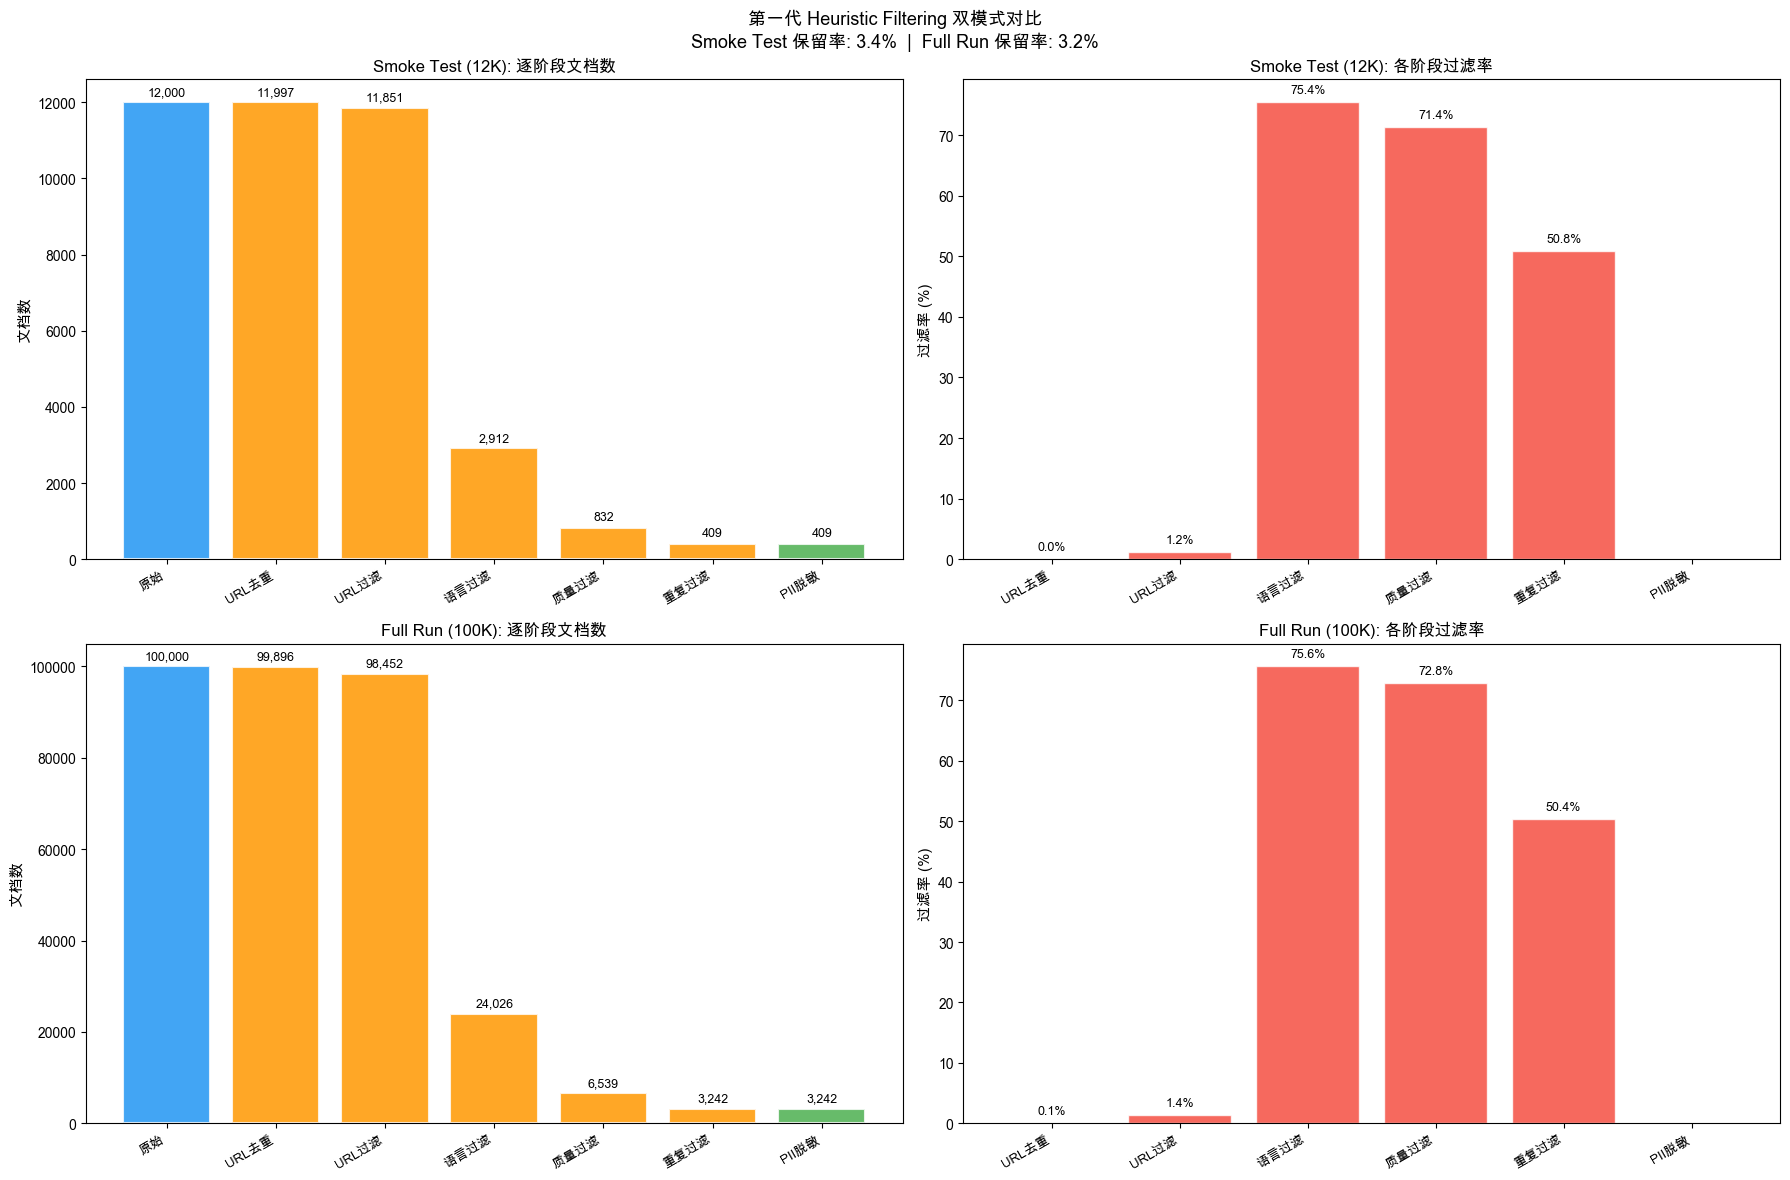

In [11]:
# === Cell 10: 双模式瀑布图（2x2 布局） ===
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

step_names_ordered = {
    'url_dedup': 'URL去重',
    'url_filter': 'URL过滤',
    'language_filter': '语言过滤',
    'quality_filter': '质量过滤',
    'repetition_filter': '重复过滤',
    'pii_filter': 'PII脱敏',
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for row_idx, mode in enumerate(MODES):
    d = dual_data[mode]
    label = MODE_LABELS[mode]

    stages = ['原始']
    counts = [d['input_count']]
    filter_rates = [0.0]

    for s in d['pipeline_stats']:
        stage_label = step_names_ordered.get(s['step'], s['step'])
        stages.append(stage_label)
        counts.append(s['after'])
        filter_rates.append(s['filter_rate'])

    ax1 = axes[row_idx, 0]
    ax2 = axes[row_idx, 1]

    # 文档数瀑布
    colors = ['#2196F3' if i == 0
              else '#4CAF50' if i == len(counts) - 1
              else '#FF9800'
              for i in range(len(counts))]
    bars = ax1.bar(stages, counts, color=colors, alpha=0.85,
                   edgecolor='white', linewidth=1.5)
    ax1.set_ylabel('文档数', fontsize=11)
    ax1.set_title(f'{label}: 逐阶段文档数', fontweight='bold', fontsize=12)
    ax1.set_xticklabels(stages, rotation=30, ha='right', fontsize=9.5)
    for bar, count in zip(bars, counts):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(counts) * 0.01,
                 f'{count:,}', ha='center', va='bottom', fontsize=9)

    # 过滤率条形图
    ax2.bar(stages[1:], [r * 100 for r in filter_rates[1:]],
            color='#f44336', alpha=0.8, edgecolor='white')
    ax2.set_ylabel('过滤率 (%)', fontsize=11)
    ax2.set_title(f'{label}: 各阶段过滤率', fontweight='bold', fontsize=12)
    ax2.set_xticklabels(stages[1:], rotation=30, ha='right', fontsize=9.5)
    for j, r in enumerate(filter_rates[1:]):
        if r > 0:
            ax2.text(j, r * 100 + 1, f'{r:.1%}', ha='center', va='bottom', fontsize=9)

plt.suptitle(
    f'第一代 Heuristic Filtering 双模式对比\n'
    f'Smoke Test 保留率: {dual_data["smoke_test"]["retention_rate"]:.1%}  |  '
    f'Full Run 保留率: {dual_data["full_run"]["retention_rate"]:.1%}',
    fontweight='bold', fontsize=13
)
plt.tight_layout()

import os
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/02_gen1_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

### 瀑布图解读

> **口径说明**：每步的柱高 = 该步输出文档数（分子）/ 原始输入文档数（分母），即 e2e 保留率

**核心观察**：
1. **语言过滤（Step 2）是最大断崖**：从 100% 直降至 ~24%，因 CC WET 随机 segment 英文占比仅 ~25%
2. **质量+重复过滤渐进衰减**：Step 3（质量）和 Step 4（重复）各再削减一半，形成阶梯式下降
3. **两档一致性**：smoke_test 和 full_run 的瀑布形态高度吻合，说明 12K 样本具有统计代表性
4. **最终保留率 ~3.2%**：远低于论文预期的 30-40%，主因是数据源语言分布差异（论文使用英文为主的 CC WARC）

## H. 过滤贡献分解（含子过滤器级别）

In [12]:
# === Cell 11: 过滤贡献分解（大类 + 小类） ===
for mode in MODES:
    d = dual_data[mode]
    label = MODE_LABELS[mode]
    total_filtered = d['input_count'] - d['output_count']

    # --- 大类 + 小类行 ---
    contrib_rows = []
    for s in d['pipeline_stats']:
        name = step_names.get(s['step'], s['step'])
        if s['filtered'] > 0:
            pct_total = s['filtered'] / total_filtered
            pct_input = s['filter_rate']
            contrib_rows.append({
                '过滤器': name,
                '过滤数': s['filtered'],
                '占总过滤（分子=该步过滤数, 分母=总过滤数）': f"{pct_total:.1%}",
                '占该步输入（分子=该步过滤数, 分母=该步输入数）': f"{pct_input:.1%}",
            })

            # 子过滤器分解
            rb = s.get('reason_breakdown', {})
            if rb and len(rb) > 1:
                for reason, count in sorted(rb.items(), key=lambda x: -x[1]):
                    pct_sub = count / s['filtered']
                    contrib_rows.append({
                        '过滤器': f"  -> {reason}",
                        '过滤数': count,
                        '占总过滤（分子=该步过滤数, 分母=总过滤数）': '',
                        '占该步输入（分子=该步过滤数, 分母=该步输入数）': f"({pct_sub:.0%} of this filter)",
                    })

    df_contrib = pd.DataFrame(contrib_rows)
    print(f"[{label}] 总过滤: {total_filtered:,} 条")
    display(df_contrib)
    print()

[Smoke Test (12K)] 总过滤: 11,591 条


,过滤器,过滤数,"占总过滤（分子=该步过滤数, 分母=总过滤数）","占该步输入（分子=该步过滤数, 分母=该步输入数）"
0,URL 去重,3,0.0%,0.0%
1,URL 过滤,146,1.3%,1.2%
2,-> blacklist_keyword,135,,(92% of this filter)
3,-> ip_address_url,7,,(5% of this filter)
4,-> blacklist_tld,4,,(3% of this filter)
5,语言过滤,8939,77.1%,75.4%
6,质量过滤(Gopher+C4+FineWeb),2080,17.9%,71.4%
7,-> c4,1210,,(58% of this filter)
8,-> gopher,870,,(42% of this filter)
9,重复过滤,423,3.6%,50.8%



[Full Run (100K)] 总过滤: 96,758 条


,过滤器,过滤数,"占总过滤（分子=该步过滤数, 分母=总过滤数）","占该步输入（分子=该步过滤数, 分母=该步输入数）"
0,URL 去重,104,0.1%,0.1%
1,URL 过滤,1444,1.5%,1.4%
2,-> blacklist_keyword,1377,,(95% of this filter)
3,-> ip_address_url,44,,(3% of this filter)
4,-> blacklist_tld,23,,(2% of this filter)
5,语言过滤,74426,76.9%,75.6%
6,质量过滤(Gopher+C4+FineWeb),17487,18.1%,72.8%
7,-> c4,9927,,(57% of this filter)
8,-> gopher,7560,,(43% of this filter)
9,重复过滤,3297,3.4%,50.4%


## I. 第一代汇总结论

In [13]:
# === Cell 12: 最终汇总（DataFrame + 结论） ===
_ML = {'smoke_test': 'ST(12K)', 'full_run': 'FR(100K)'}

summary_rows = []
for mode in MODES:
    d = dual_data[mode]
    ml = _ML[mode]
    output_metrics = [m for m in d['stage_metrics'] if m.get('stage') == 'gen1_output']
    est_tokens = output_metrics[0].get('estimated_total_tokens', 0) if output_metrics else 0
    avg_tokens = output_metrics[0].get('avg_tokens_per_doc', 0) if output_metrics else 0
    
    summary_rows.append({
        '指标': '输入文档数',
        ml: f"{d['input_count']:,}",
    })
    summary_rows.append({
        '指标': '输出文档数',
        ml: f"{d['output_count']:,}",
    })
    summary_rows.append({
        '指标': 'e2e 保留率',
        ml: f"{d['retention_rate']:.2%}",
    })
    summary_rows.append({
        '指标': '估算 Token 数',
        ml: f"{est_tokens:,}",
    })
    summary_rows.append({
        '指标': '平均 Token/文档',
        ml: f"{avg_tokens:,.1f}",
    })

# Pivot into a single table with one row per metric
metrics = ['输入文档数', '输出文档数', 'e2e 保留率', '估算 Token 数', '平均 Token/文档']
final_rows = []
for metric in metrics:
    row = {'指标': metric}
    for mode in MODES:
        ml = _ML[mode]
        for r in summary_rows:
            if r['指标'] == metric and ml in r:
                row[ml] = r[ml]
    row['口径说明'] = {
        '输入文档数': '原始 CC WET 加载文档数',
        '输出文档数': '通过全部 6 步过滤后的文档数',
        'e2e 保留率': '分子=输出文档数, 分母=输入文档数',
        '估算 Token 数': '输出文档的 GPT-2 tokenizer 总 token 数',
        '平均 Token/文档': '估算 Token 数 / 输出文档数',
    }.get(metric, '')
    row['论文参考值'] = {
        'e2e 保留率': '30-40%（FineWeb/Gopher）',
    }.get(metric, '')
    final_rows.append(row)

final_df = pd.DataFrame(final_rows)

print("=" * 80)
print("  第一代 Heuristic Filtering — 最终汇总")
print("=" * 80)
display(final_df)

# 关键发现
print()
print("关键发现：")
print("  1. 语言过滤是最大的过滤器（~75%），因为 CC WET 英文占比仅 ~25-35%")
print("  2. 质量过滤（Gopher+C4）过滤 ~70% 的英文文档，主要是短文本和低标点率")
print("  3. 重复过滤再过滤 ~50%，主要触发规则是 5-gram 重复（模板/导航内容）")
print("  4. 两档（12K/100K）保留率一致（~3.2-3.4%），smoke_test 代表性良好")
print("  5. FineWeb 补充规则未触发，说明 Gopher+C4 已覆盖了大部分低质量内容")
print()
print("  下一步 -> NB03：第二代 Model-based Filtering")
print('  预期：fastText 分类器将进一步区分"平庸内容"和"高质量内容"')

  第一代 Heuristic Filtering — 最终汇总


,指标,ST(12K),FR(100K),口径说明,论文参考值
0,输入文档数,"12,000","100,000",原始 CC WET 加载文档数,
1,输出文档数,409,"3,242",通过全部 6 步过滤后的文档数,
2,e2e 保留率,3.41%,3.24%,"分子=输出文档数, 分母=输入文档数",30-40%（FineWeb/Gopher）
3,估算 Token 数,"422,611","3,757,931",输出文档的 GPT-2 tokenizer 总 token 数,
4,平均 Token/文档,"1,033.3","1,159.1",估算 Token 数 / 输出文档数,



关键发现：
  1. 语言过滤是最大的过滤器（~75%），因为 CC WET 英文占比仅 ~25-35%
  2. 质量过滤（Gopher+C4）过滤 ~70% 的英文文档，主要是短文本和低标点率
  3. 重复过滤再过滤 ~50%，主要触发规则是 5-gram 重复（模板/导航内容）
  4. 两档（12K/100K）保留率一致（~3.2-3.4%），smoke_test 代表性良好
  5. FineWeb 补充规则未触发，说明 Gopher+C4 已覆盖了大部分低质量内容

  下一步 -> NB03：第二代 Model-based Filtering
  预期：fastText 分类器将进一步区分"平庸内容"和"高质量内容"


In [14]:
# === Cell 13: 保存五维 Profile（per-mode） ===
import os
os.makedirs('../results', exist_ok=True)

profiles = {
    'gen1_input': input_profile,
    'gen1_output': output_profile,
}

# Per-mode file for dual-mode comparison
per_mode_path = f'../results/gen1_5dim_profile_{mode}.json'
with open(per_mode_path, 'w', encoding='utf-8') as f:
    json.dump(profiles, f, ensure_ascii=False, indent=2, default=str)

# Legacy file (always latest)
legacy_path = '../results/gen1_5dim_profile.json'
with open(legacy_path, 'w', encoding='utf-8') as f:
    json.dump(profiles, f, ensure_ascii=False, indent=2, default=str)

print(f"五维 Profile 已保存: {per_mode_path}")

五维 Profile 已保存: ../results/gen1_5dim_profile_full_run.json
